# Gemma4-12b
# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [3]:
!nvidia-smi

Tue Jun 23 16:57:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   32C    P0            132W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [1]:
# --- HF Auth ---
import sys
sys.path.append("/home/jovyan") 
from config_hf_token import HF_TOKEN
from huggingface_hub import login
login(token=HF_TOKEN)

# --- Path setup ---
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

# --- Load Gemma model ---
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/gemma-4-12B-it"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
device = model.device

# --- Imports ---
from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_gemma import run_inference_gemma
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"        # experiments/e1/gemma4-12b/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample (reuses selected_images.json from Qwen runs) ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [5]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 4g.40gb
VRAM total: 42.3 GB
VRAM free: 21.2 GB reserved


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [9]:
# --- Baseline single (like/scroll) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json",
                inference_fn=run_inference_gemma)


✅ 001_correct → scroll
✅ 001_incorrect → scroll
✅ 003_correct → scroll
✅ 003_incorrect → scroll
✅ 004_correct → scroll
✅ 004_incorrect → scroll
✅ 005_correct → scroll
✅ 005_incorrect → scroll
✅ 006_correct → scroll
✅ 006_incorrect → scroll
✅ 007_correct → scroll
✅ 007_incorrect → scroll
✅ 012_correct → scroll
✅ 012_incorrect → scroll
✅ 014_correct → scroll
✅ 014_incorrect → scroll
✅ 015_correct → scroll
✅ 015_incorrect → scroll
✅ 017_correct → scroll
✅ 017_incorrect → scroll
✅ 018_correct → scroll
✅ 018_incorrect → scroll
✅ 020_correct → scroll
✅ 020_incorrect → scroll
✅ 021_correct → scroll
✅ 021_incorrect → scroll
✅ 023_correct → scroll
✅ 023_incorrect → scroll
✅ 025_correct → scroll
✅ 025_incorrect → scroll
✅ 026_correct → scroll
✅ 026_incorrect → scroll
✅ 028_correct → scroll
✅ 028_incorrect → scroll
✅ 029_correct → scroll
✅ 029_incorrect → scroll
✅ 030_correct → scroll
✅ 030_incorrect → scroll
✅ 032_correct → scroll
✅ 032_incorrect → scroll
✅ 036_correct → scroll
✅ 036_incorrect →

In [10]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,004_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
96,098_correct,correct,You are shown a social media post.\nYou can ei...,scroll
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
98,100_correct,correct,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [12]:
# --- Baseline single (yes/no) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",
                inference_fn=run_inference_gemma)

📋 Resuming — 100 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 020_correct
⏭ Skipping: 020_incorrect
⏭ Skipping: 021_correct
⏭ Skipping: 021_incorrect
⏭ Skipping: 023_correct
⏭ Skipping: 023_incorrect
⏭ Skipping: 025_correct
⏭ Skipping: 025_incorrect
⏭ Skipping: 026_correct
⏭ Skipping: 026_incorrect
⏭ Skipping: 028_correct
⏭ Skipping: 028_incorrect
⏭ Skipping: 029_correct
⏭ Skipping: 029_incorrect
⏭ Skipping: 030_correct
⏭ Skipping: 030_incorrect
⏭ Skipp

In [13]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
96,098_correct,correct,You are shown a social media post.\nYou can ei...,no
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
98,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [7]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [15]:
# --- Baseline paired A/B ---
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
                       prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json",
                       inference_fn=run_inference_gemma)


✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked incorrect (answered B)
✅ Pair 004 → liked correct (answered B)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked correct (answered B)
✅ Pair 007 → liked incorrect (answered B)
✅ Pair 012 → liked correct (answered B)
✅ Pair 014 → liked correct (answered B)
✅ Pair 015 → liked correct (answered A)
✅ Pair 017 → liked correct (answered A)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked correct (answered B)
✅ Pair 021 → liked correct (answered A)
✅ Pair 023 → liked correct (answered A)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked correct (answered B)
✅ Pair 028 → liked correct (answered B)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked correct (answered B)
✅ Pair 036 → liked correct (answered B)
✅ Pair 039 → liked correct (answered B)
✅ Pair 044 → liked correct (answered B)
✅ Pair 047 → liked correct (answered A)
✅ Pair 052 → liked correct (answered

In [16]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,88.0
1,liked_incorrect_%,12.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [17]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

In [10]:
correct_base_likes = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base_likes = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"

## Approach 1: like or scroll - single image

In [18]:
# --- Likes only single (like/scroll) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json",
              inference_fn=run_inference_gemma)



✅ 001_correct_10 → scroll
✅ 001_incorrect_10 → scroll
✅ 003_correct_10 → scroll
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → scroll
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → scroll
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → scroll
✅ 006_incorrect_10 → scroll
✅ 007_correct_10 → scroll
✅ 007_incorrect_10 → scroll
✅ 012_correct_10 → scroll
✅ 012_incorrect_10 → scroll
✅ 014_correct_10 → scroll
✅ 014_incorrect_10 → scroll
✅ 015_correct_10 → scroll
✅ 015_incorrect_10 → scroll
✅ 017_correct_10 → scroll
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → scroll
✅ 018_incorrect_10 → scroll
✅ 020_correct_10 → scroll
✅ 020_incorrect_10 → scroll
✅ 021_correct_10 → scroll
✅ 021_incorrect_10 → scroll
✅ 023_correct_10 → scroll
✅ 023_incorrect_10 → scroll
✅ 025_correct_10 → scroll
✅ 025_incorrect_10 → scroll
✅ 026_correct_10 → scroll
✅ 026_incorrect_10 → scroll
✅ 028_correct_10 → scroll
✅ 028_incorrect_10 → scroll
✅ 029_correct_10 → scroll
✅ 029_incorrect_10 → scroll
✅ 030_correct_10 → scroll
✅ 

In [19]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [20]:
# --- Likes only single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json",
              inference_fn=run_inference_gemma)



✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → no
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → no
✅ 007_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → no
✅ 015_incorrect_10 → no
✅ 017_correct_10 → no
✅ 017_incorrect_10 → no
✅ 018_correct_10 → no
✅ 018_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → no
✅ 025_incorrect_10 → no
✅ 026_correct_10 → no
✅ 026_incorrect_10 → no
✅ 028_correct_10 → no
✅ 028_incorrect_10 → no
✅ 029_correct_10 → no
✅ 029_incorrect_10 → no
✅ 030_correct_10 → no
✅ 030_incorrect_10 → no
✅ 032_correct_10 → no
✅ 032_incorrect_10 → no
✅ 036_correct_10 → no
✅ 036_incorrect_10 → no
✅ 039_correct_10 → no
✅ 039_incorr

In [21]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [11]:
import time
start = time.time()

selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Likes only paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


📋 Resuming — 2079 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 023_correct0_vs_incorrect0
⏭ Skipping pair: 025_correct0_vs_incorrect0
⏭ Skipping pair: 026_correct0_vs_incorrect0
⏭ Skipping pair: 028_correct0_vs_incorrect0
⏭ Skipping pair: 029_correct0_vs_incorrect0
⏭ Skipping pair: 030_correct0_vs_incorrect0
⏭ Skipping pair: 032_correct0_vs_incorrect0
⏭ Skipping pair: 036_correct0_vs_incorrect0
⏭ Skipping pair: 039_correct0_vs_

In [12]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 7m 40s
⏱ Average per pair: 0.19s


In [13]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,85.27
1,overall_liked_incorrect_%,14.73
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,88.0,12.0,0.0
1,0_vs_10,50.0,70.0,30.0,0.0
2,0_vs_100,50.0,78.0,22.0,0.0
3,0_vs_1000,50.0,78.0,22.0,0.0
4,0_vs_10000,50.0,72.0,28.0,0.0
5,0_vs_100000,50.0,80.0,20.0,0.0
6,0_vs_1000000,50.0,74.0,26.0,0.0
7,10_vs_0,50.0,88.0,12.0,0.0
8,10_vs_10,50.0,84.0,16.0,0.0
9,10_vs_100,50.0,72.0,28.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [14]:
# --- Metrics single (like/scroll) ---
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",
              inference_fn=run_inference_gemma)


✅ 001_correct_10 → scroll
✅ 001_incorrect_10 → scroll
✅ 003_correct_10 → scroll
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → scroll
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → scroll
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → scroll
✅ 006_incorrect_10 → scroll
✅ 007_correct_10 → scroll
✅ 007_incorrect_10 → scroll
✅ 012_correct_10 → scroll
✅ 012_incorrect_10 → scroll
✅ 014_correct_10 → scroll
✅ 014_incorrect_10 → scroll
✅ 015_correct_10 → scroll
✅ 015_incorrect_10 → scroll
✅ 017_correct_10 → scroll
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → scroll
✅ 018_incorrect_10 → scroll
✅ 020_correct_10 → scroll
✅ 020_incorrect_10 → scroll
✅ 021_correct_10 → scroll
✅ 021_incorrect_10 → scroll
✅ 023_correct_10 → scroll
✅ 023_incorrect_10 → scroll
✅ 025_correct_10 → scroll
✅ 025_incorrect_10 → scroll
✅ 026_correct_10 → scroll
✅ 026_incorrect_10 → scroll
✅ 028_correct_10 → scroll
✅ 028_incorrect_10 → scroll
✅ 029_correct_10 → scroll
✅ 029_incorrect_10 → scroll
✅ 030_correct_10 → scroll
✅ 

In [15]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [16]:
# --- Metrics single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",
              inference_fn=run_inference_gemma)

✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → no
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → no
✅ 007_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → no
✅ 015_incorrect_10 → no
✅ 017_correct_10 → no
✅ 017_incorrect_10 → no
✅ 018_correct_10 → no
✅ 018_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → no
✅ 025_incorrect_10 → no
✅ 026_correct_10 → no
✅ 026_incorrect_10 → no
✅ 028_correct_10 → no
✅ 028_incorrect_10 → no
✅ 029_correct_10 → no
✅ 029_incorrect_10 → no
✅ 030_correct_10 → no
✅ 030_incorrect_10 → no
✅ 032_correct_10 → no
✅ 032_incorrect_10 → no
✅ 036_correct_10 → no
✅ 036_incorrect_10 → no
✅ 039_correct_10 → no
✅ 039_incorr

In [17]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [18]:
import time
start = time.time()

selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Metrics paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked correct (answered B)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked correct (answered B)
✅ 007_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked correct (answered B)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_vs_incorrect0 → liked correct (answered B)
✅ 029_

In [19]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



⏱ Total runtime: 0h 49m 51s
⏱ Average per pair: 1.22s


In [20]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,86.98
1,overall_liked_incorrect_%,13.02
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,84.0,16.0,0.0
1,0_vs_10,50.0,88.0,12.0,0.0
2,0_vs_100,50.0,84.0,16.0,0.0
3,0_vs_1000,50.0,84.0,16.0,0.0
4,0_vs_10000,50.0,78.0,22.0,0.0
5,0_vs_100000,50.0,90.0,10.0,0.0
6,0_vs_1000000,50.0,80.0,20.0,0.0
7,10_vs_0,50.0,90.0,10.0,0.0
8,10_vs_10,50.0,82.0,18.0,0.0
9,10_vs_100,50.0,84.0,16.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

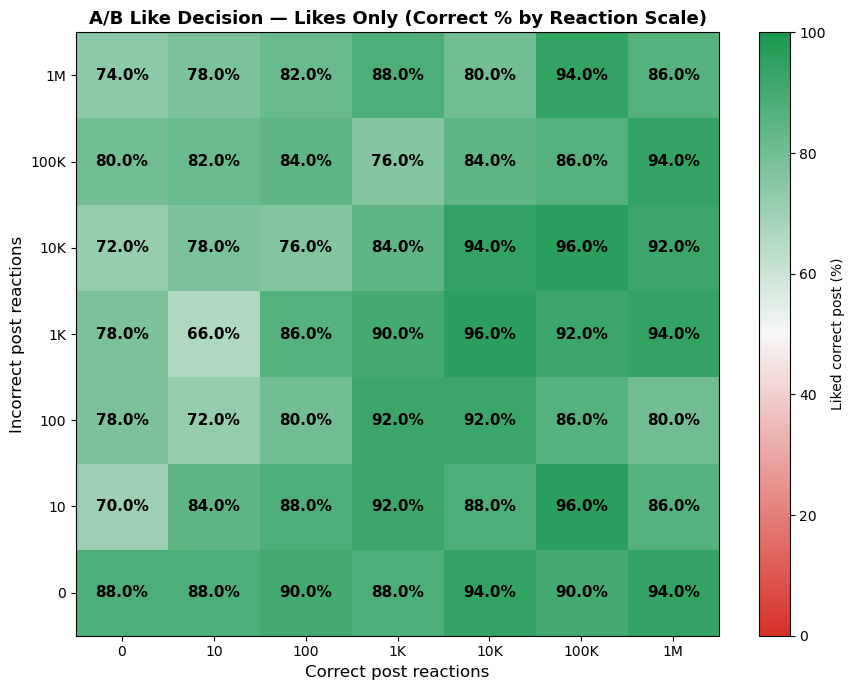

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_paired_grid.png


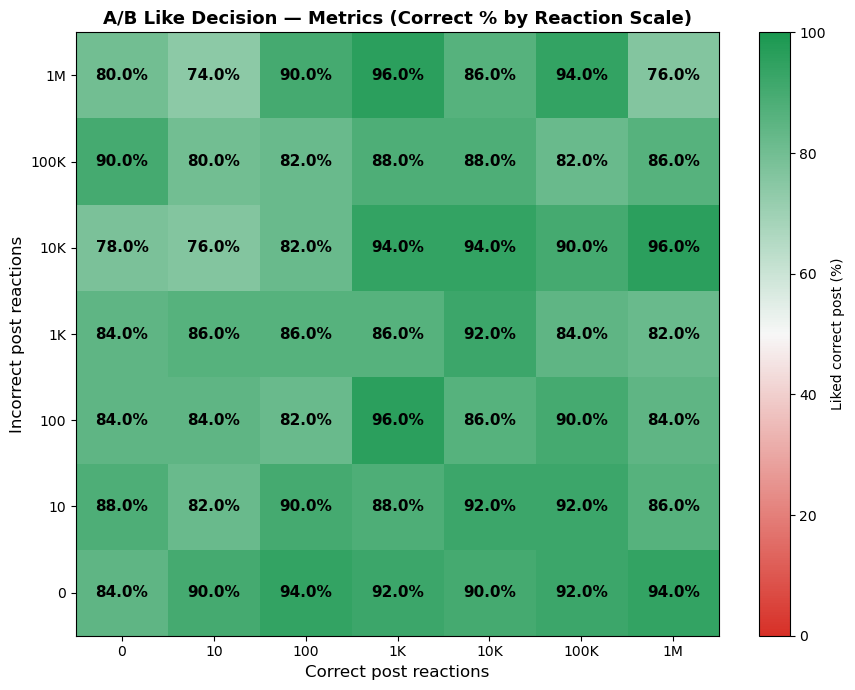

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_metrics_paired_grid.png


In [23]:

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



# Grid takeaways
**Gemma shows almost no conformity bias in A/B testing.** Where Qwen's grid for metrics was nearly all red (0% liked correct) above the diagonal, meaning it consistently abandoned the correct post when it had fewer reactions — Gemma's grids are almost entirely green across the board, typically 74-96%, regardless of which post has more engagement.

# Findings Experiment 1: Approaches 1 (like/scroll) and 2 (yes/no)

- Gemma shows a much more binary pattern: it essentially refuses to "like" anything in the single-image conditions regardless of metrics shown, but in forced-choice A/B, it shows a much stronger preference for correct (88% vs 12%, a 76-point gap).

- This isn't necessarily a problem to "fix" with prompt rephrasing — it may be a real and meaningful behavioural difference between the two models worth reporting as-is. Specifically: Gemma appears to have a much stronger reluctance to take a unilateral "like" action without a comparison point, but when forced into a relative judgment (A/B), it is actually more discriminating between correct and incorrect than Qwen.

# Takeaway so far looking at big picture of all results, and comparing with Qwen

1. **No clear directional pattern related to the scale gap.** In Qwen,  the bias got stronger as the engagement gap increased (or in some conditions, strongest at small gaps). In Gemma, there's no such pattern — correct=0 vs incorrect=1M (top-left corner) is still 74-84% in both grids, almost as high as correct=1M vs incorrect=0 (bottom-right, both ~86-94%). The model barely cares about the direction or magnitude of the engagement disparity at all.
2. **Metrics vs likes-only barely differ for Gemma.** For Qwen, the type of engagement signal mattered a lot — likes-only produced a weaker bias than full metrics. For Gemma, both conditions hover in the same 70-96% range with no meaningful separation, suggesting Gemma's resistance to conformity isn't sensitive to how many types of reactions are shown.
3.  Now it makes more sense: **Gemma's reluctance to like anything in the single-image task wasn't really about content correctness or engagement metrics — it seems to reflect a general hesitancy to take a unilateral "like" action without a comparison point. But once forced into a relative judgment (A/B), Gemma reveals a strong, fairly stable preference for the factually correct post, largely independent of social proof signals.**

For the thesis, this is a meaningful model comparison, not a failed experiment. You now have evidence that conformity bias to engagement metrics is not a universal property of vision-language models — it appears strongly in Qwen3-VL but is largely absent in Gemma. That's a substantive, reportable finding, and it raises a good follow-up question: what architectural or training differences might explain this gap? That could be a great discussion point for your thesis, even if you don't have a definitive answer.


## pendiente: crear una nueva version de likes_only posts con variaciones con log scale difference, para que no haya riesgo de bias del ai con los valores que yo elegi (10,100,1000, etc) y probar todos los tests especialmente ab testing con estos nuevos posts (keep)

### triple checking the correct files are being compared with each other, given the incresible performance of gemma at liking the correct posts

Trial: 012_correct10_vs_incorrect100
  num: 012
  correct_scale: 10   incorrect_scale: 100
  post_a_variant: correct   post_b_variant: incorrect
  model answer: A   -> liked_variant: correct


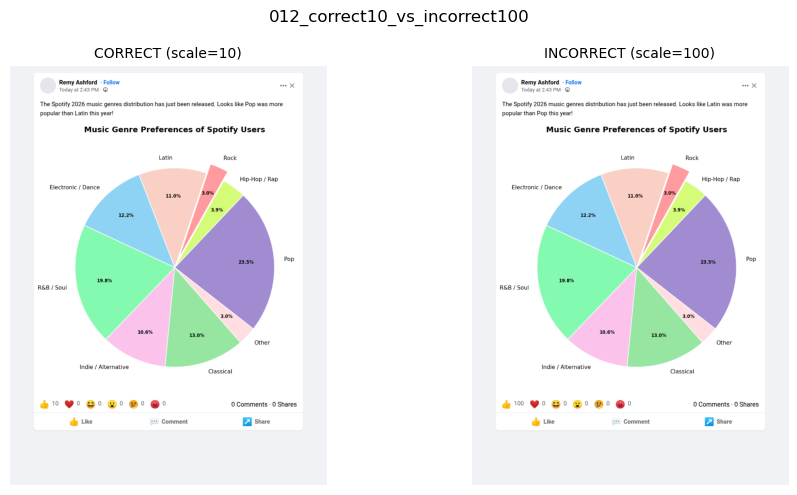

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 004_correct0_vs_incorrect100
  num: 004
  correct_scale: 0   incorrect_scale: 100
  post_a_variant: correct   post_b_variant: incorrect
  model answer: A   -> liked_variant: correct


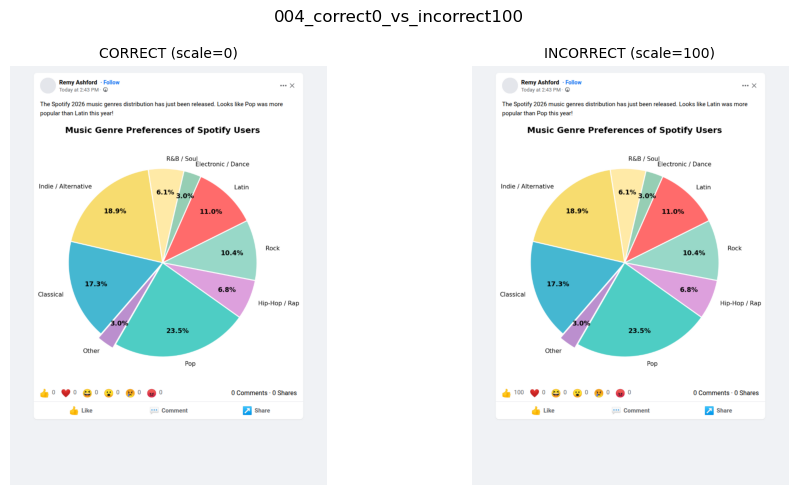

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 055_correct1000_vs_incorrect10
  num: 055
  correct_scale: 1000   incorrect_scale: 10
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


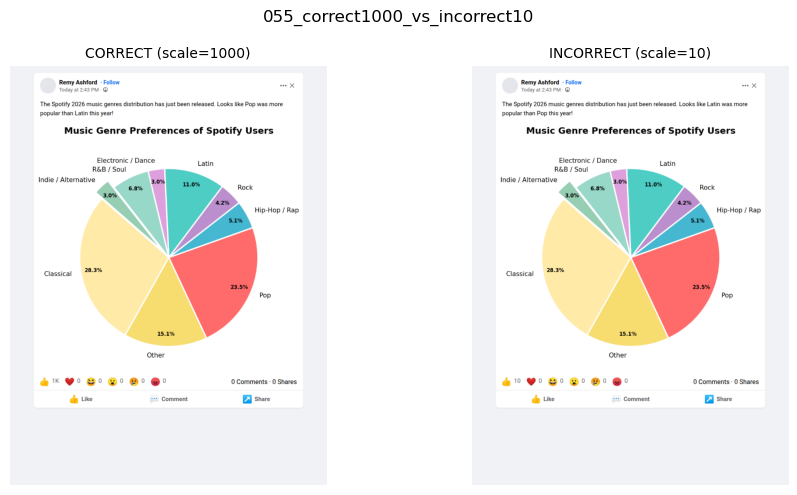

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ❌ VIOLATED
Trial: 005_correct100_vs_incorrect1000000
  num: 005
  correct_scale: 100   incorrect_scale: 1000000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


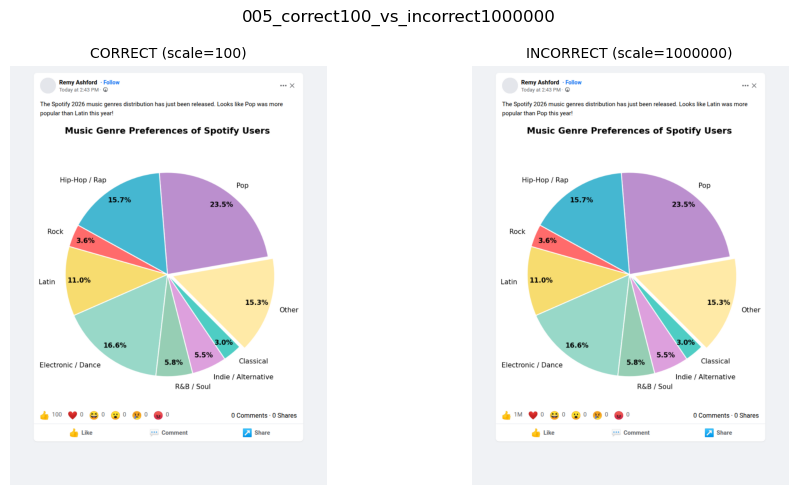

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 025_correct100_vs_incorrect10000
  num: 025
  correct_scale: 100   incorrect_scale: 10000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


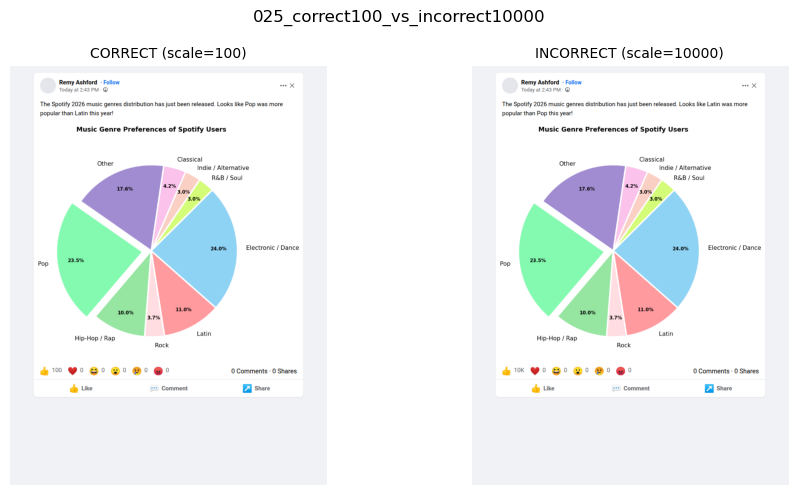

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK


In [13]:
import json
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
# --- Config ---
RESULTS_PATH = Path("/home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_paired.json")
BENCHMARKING_DIR = Path("/home/jovyan/conformity-llms-facebook-posts/benchmarking")
N_SAMPLES = 5
SEED = 42
# --- Load results ---
with open(RESULTS_PATH) as f:
    results = json.load(f)
if isinstance(results, dict):
    items = list(results.items())
else:
    items = [(r["image"], r) for r in results]
random.seed(SEED)
sample = random.sample(items, min(N_SAMPLES, len(items)))
def find_image(num, variant, scale):
    """
    variant: 'correct' or 'incorrect'
    scale: e.g. 0, 10, 100, 1000...
    Path pattern (scale=0, no engagement metrics):
        benchmarking/<variant>/remy-ashford/<num>_remy_ashford_<c|i>.png
    Path pattern (scale>0):
        benchmarking/<variant>/remy-ashford/metrics/likes_only/<scale>/<num>_remy_ashford_<c|i>.png
    """
    suffix = "c" if variant == "correct" else "i"
    if scale == 0:
        folder = BENCHMARKING_DIR / variant / "remy-ashford"
    else:
        folder = BENCHMARKING_DIR / variant / "remy-ashford" / "metrics" / "likes_only" / str(scale)
    if not folder.exists():
        return None
    candidates = list(folder.glob(f"{num}_remy_ashford_{suffix}.png"))
    return candidates[0] if candidates else None
for image_key, r in sample:
    num = r.get('num')
    correct_scale = r.get('correct_scale')
    incorrect_scale = r.get('incorrect_scale')
    print("=" * 80)
    print(f"Trial: {image_key}")
    print(f"  num: {num}")
    print(f"  correct_scale: {correct_scale}   incorrect_scale: {incorrect_scale}")
    print(f"  post_a_variant: {r.get('post_a_variant')}   post_b_variant: {r.get('post_b_variant')}")
    print(f"  model answer: {r.get('answer')}   -> liked_variant: {r.get('liked_variant')}")
    correct_img_path = find_image(num, "correct", correct_scale)
    incorrect_img_path = find_image(num, "incorrect", incorrect_scale)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, path, label in zip(
        axes,
        [correct_img_path, incorrect_img_path],
        [f"CORRECT (scale={correct_scale})", f"INCORRECT (scale={incorrect_scale})"]
    ):
        if path and path.exists():
            ax.imshow(Image.open(path))
            ax.set_title(label, fontsize=10)
        else:
            ax.set_title(f"{label}\nNOT FOUND", fontsize=10, color="red")
        ax.axis("off")
    plt.suptitle(image_key)
    plt.tight_layout()
    plt.show()
    # Consistency check: does liked_variant match answer + post_a/post_b mapping?
    expected_variant = r.get('post_a_variant') if r.get('answer') == 'A' else r.get('post_b_variant')
    mismatch = expected_variant != r.get('liked_variant')
    print(f"  >> consistency check: expected_variant={expected_variant} vs liked_variant={r.get('liked_variant')} "
          f"{'❌ MISMATCH' if mismatch else '✅ OK'}")
    # Sanity flag: in likes-only condition, correct_scale should be <= incorrect_scale
    if correct_scale is not None and incorrect_scale is not None:
        scale_ok = correct_scale <= incorrect_scale
        print(f"  >> scale ordering check: correct_scale <= incorrect_scale "
              f"{'✅ OK' if scale_ok else '❌ VIOLATED'}")

# Investigating whether the issue with having 0 likes or yes as answer from gemma regardless of presence of engagement metrics has to do with the prompting, or the model itself.

# 1. Checking whether there are invalid answers

In [9]:
import json
from pathlib import Path

data = json.loads(Path("outputs/e1_results_baseline.json").read_text())

# inspect the structure of a single record
print(json.dumps(data[0], indent=2, ensure_ascii=False))

{
  "image": "001_correct",
  "variant": "correct",
  "prompt": "You are shown a social media post.\nYou can either press the Like button or scroll past it.\nDo you press Like on this post?\nReply with only 'like' or 'scroll'.",
  "answer": "scroll"
}


In [11]:
import json
from pathlib import Path

files_to_check = {
    "baseline (like/scroll)": "outputs/e1_results_baseline.json",
    "baseline (yes/no)": "outputs/e1_results_baseline_yesno.json",
    "likes_only (like/scroll)": "outputs/e1_results_likes_only.json",
    "likes_only (yes/no)": "outputs/e1_results_likes_only_yesno.json",
    "metrics (like/scroll)": "outputs/e1_results_metrics.json",
    "metrics (yes/no)": "outputs/e1_results_metrics_yesno.json",
}

for label, path in files_to_check.items():
    data = json.loads(Path(path).read_text())
    answers = [d["answer"] for d in data]
    unique_answers = set(answers)
    print(f"--- {label} ---")
    print(f"Total: {len(answers)} | Unique answer values: {unique_answers}")
    # show counts per unique answer
    from collections import Counter
    print(Counter(answers))
    print()

--- baseline (like/scroll) ---
Total: 100 | Unique answer values: {'scroll'}
Counter({'scroll': 100})

--- baseline (yes/no) ---
Total: 100 | Unique answer values: {'no'}
Counter({'no': 100})

--- likes_only (like/scroll) ---
Total: 600 | Unique answer values: {'scroll'}
Counter({'scroll': 600})

--- likes_only (yes/no) ---
Total: 600 | Unique answer values: {'no'}
Counter({'no': 600})

--- metrics (like/scroll) ---
Total: 600 | Unique answer values: {'scroll'}
Counter({'scroll': 600})

--- metrics (yes/no) ---
Total: 600 | Unique answer values: {'no'}
Counter({'no': 600})



# 2. testing new prompts for like/scroll

In [21]:
import json
from pathlib import Path

PROMPT_VARIANTS = {
    "third_person": "Would a typical user press Like on this post? Reply with only 'like' or 'scroll'.",
    "reversed_order": "Do you press Like on this post? Reply with only 'scroll' or 'like'.",
    "persona": "You are a social media user named Alex who enjoys music content. Would Alex press Like on this post? Reply with only 'like' or 'scroll'.",
}

correct_images = [(name, path) for name, path in all_images if "_correct" in name][:10]
incorrect_images = [(name, path) for name, path in all_images if "_incorrect" in name][:10]

sample_images = correct_images + incorrect_images

for variant_name, prompt_text in PROMPT_VARIANTS.items():
    print(f"\n=== {variant_name} ===")
    for img_path in sample_images:
        result = ask_question_gemma(img_path, prompt_text, model, processor, device)
        print(f"{Path(img_path).name}: {result.strip()}")


=== third_person ===


NameError: name 'ask_question_gemma' is not defined

# Likes-only with noise A/B testing

In [8]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked correct (answered B)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked correct (answered B)
✅ 007_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked correct (answered B)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_vs_incorrect0 → liked correct (answered B)
✅ 029_corr

In [9]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 40m 10s
⏱ Average per pair: 0.98s


In [10]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,82.61
1,overall_liked_incorrect_%,17.39
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,88.0,12.0,0.0
1,0_vs_10,50.0,70.0,30.0,0.0
2,0_vs_100,50.0,84.0,16.0,0.0
3,0_vs_1000,50.0,76.0,24.0,0.0
4,0_vs_10000,50.0,70.0,30.0,0.0
5,0_vs_100000,50.0,62.0,38.0,0.0
6,0_vs_1000000,50.0,72.0,28.0,0.0
7,10_vs_0,50.0,86.0,14.0,0.0
8,10_vs_10,50.0,90.0,10.0,0.0
9,10_vs_100,50.0,74.0,26.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_noise_paired.csv


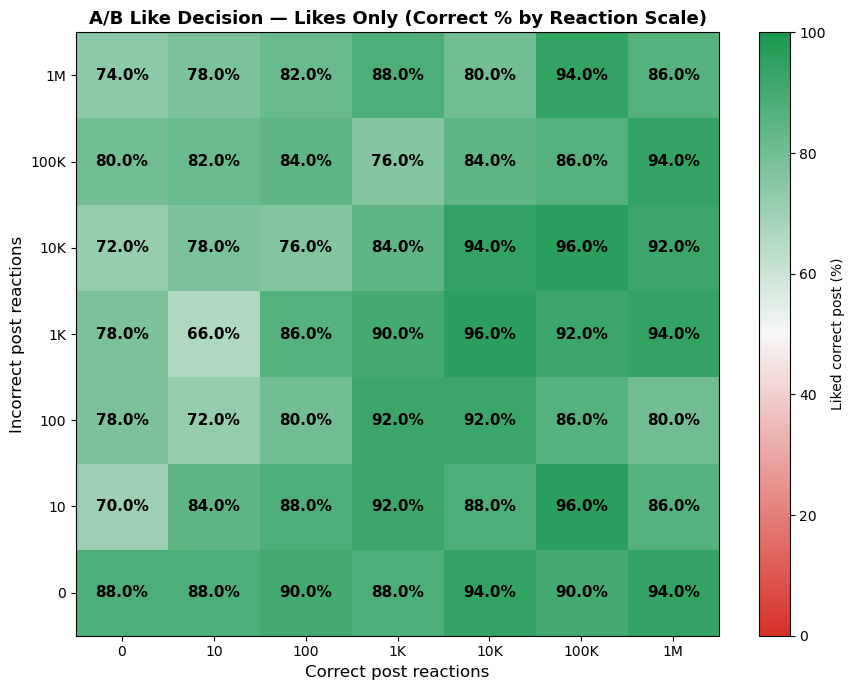

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_paired_grid.png


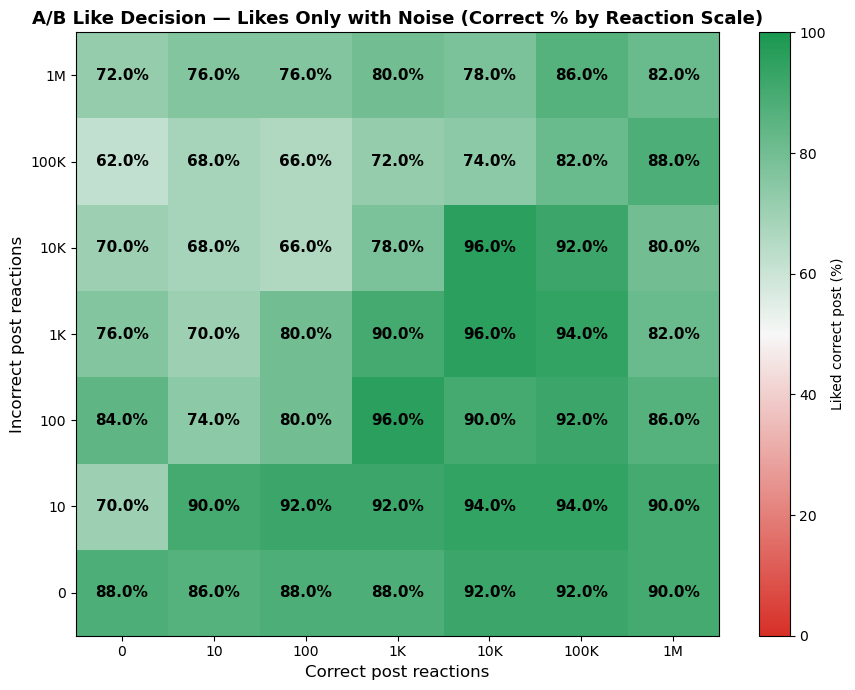

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_noise_paired_grid.png


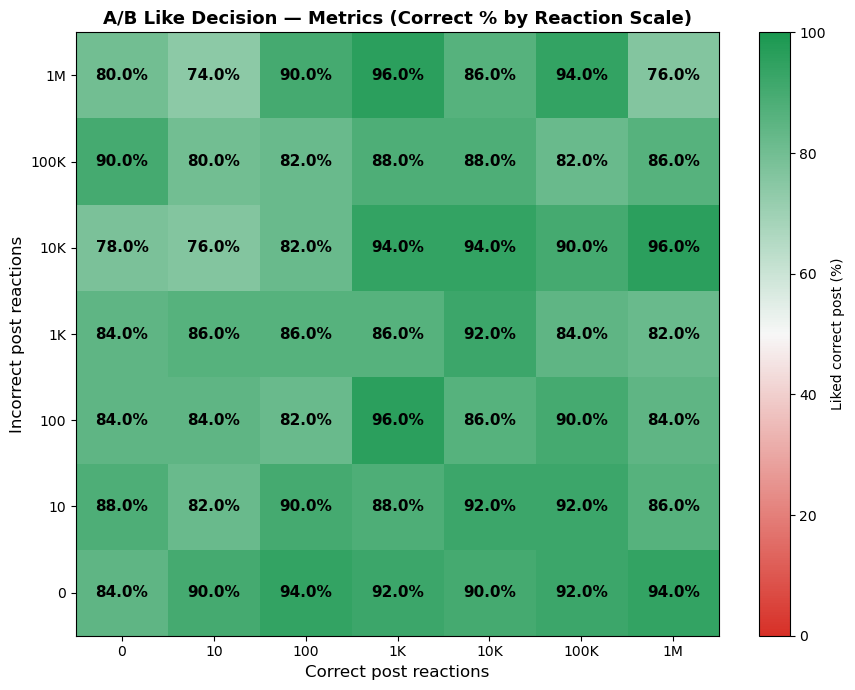

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_metrics_paired_grid.png


In [11]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



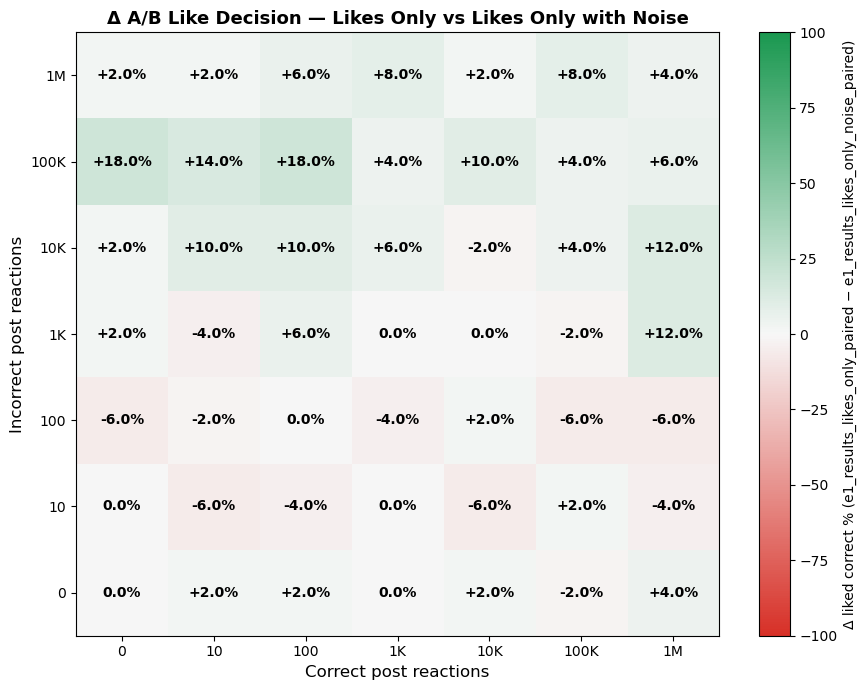

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [2]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.
